In [1]:
import subprocess
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, random_split, TensorDataset
import csv, json, time
from sklearn.metrics import f1_score
from tqdm import tqdm  # Progress bar



from input_preprocess import tokenizer
from lwm_model import lwm
from inference import lwm_inference, create_raw_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using",device)

/home/ronit/anaconda3/envs/lwm_cuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda


In [2]:
# Define scenario names and select one (or more).
scenario_names = np.array([
    "city_0_newyork", "city_1_losangeles", "city_2_chicago", "city_3_houston",
    "city_4_phoenix", "city_5_philadelphia", "city_6_miami", "city_7_sandiego",
    "city_8_dallas", "city_9_sanfrancisco", "city_10_austin", "city_11_santaclara",
    "city_12_fortworth", "city_13_columbus", "city_15_indianapolis", "city_17_seattle",
    "city_18_denver", "city_19_oklahoma", "O1_3p5B", "O1_3p5"])
#################################################### Select the first scenario (index 0) – adjust as needed##################################################
scenario_idxs = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19])[0:3]
selected_scenario_names = scenario_names[scenario_idxs]
print("selected scenarios: ")
for i in selected_scenario_names: print(i, end=", ")

selected scenarios: 
city_0_newyork, city_1_losangeles, city_2_chicago, 

In [3]:
snr_db = None
preprocessed_chs = tokenizer(
    selected_scenario_names=selected_scenario_names,
    manual_data=None,
    gen_raw=True,
    snr_db=snr_db
)


Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 5148/5148 [00:00<00:00, 39609.77it/s]



Basestation 1

UE-BS Channels


Generating channels: 100%|██████████| 4617/4617 [00:00<00:00, 62260.80it/s]



Basestation 1

UE-BS Channels


Processing items: 100%|██████████| 2308/2308 [00:00<00:00, 50179.89it/s]


In [4]:
lwm_model = lwm.from_pretrained(device=device)

Model loaded successfully from model_weights.pth to cuda


In [5]:
#######SELECT INPUT##############################################
input_types = ['cls_emb', 'channel_emb', 'raw']
selected_input_type = input_types[0] # choose one: 'cls_emb', 'channel_emb', or 'raw'
if selected_input_type in ['cls_emb', 'channel_emb']:
    dataset = lwm_inference(preprocessed_chs, selected_input_type, lwm_model, device)
else:
    dataset = create_raw_dataset(preprocessed_chs, device)
# At this point, `dataset` should be a torch Dataset yielding (data, target) pairs.


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 5148/5148 [00:00<00:00, 98593.52it/s]


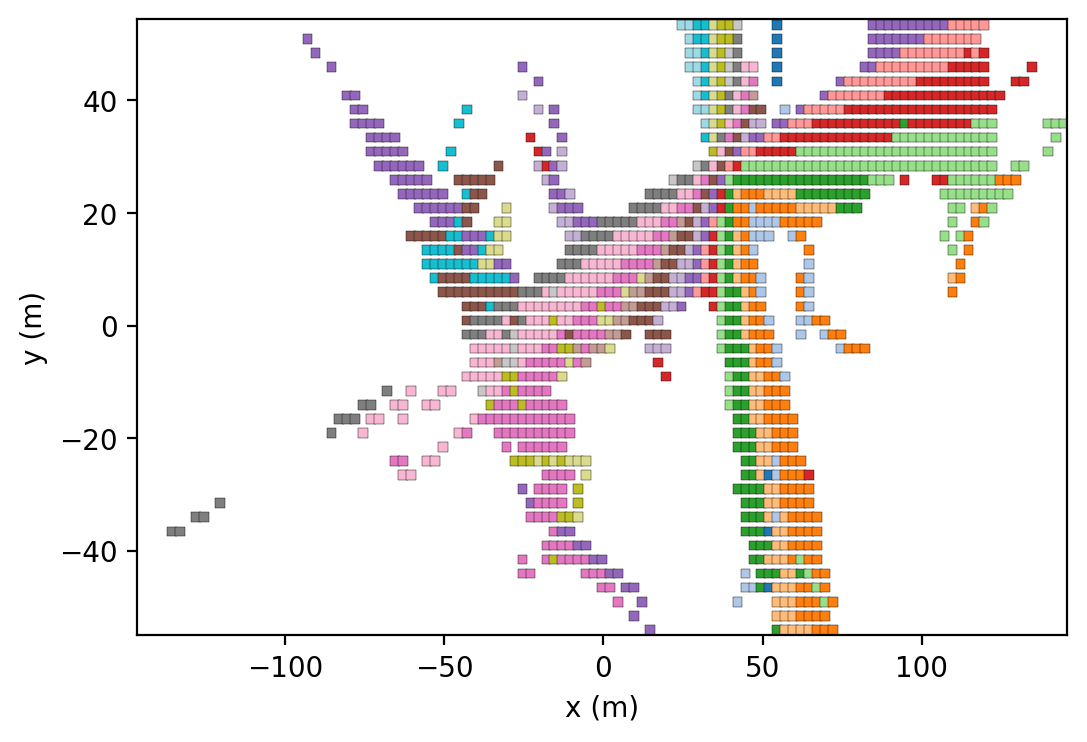


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 4617/4617 [00:00<00:00, 171193.81it/s]


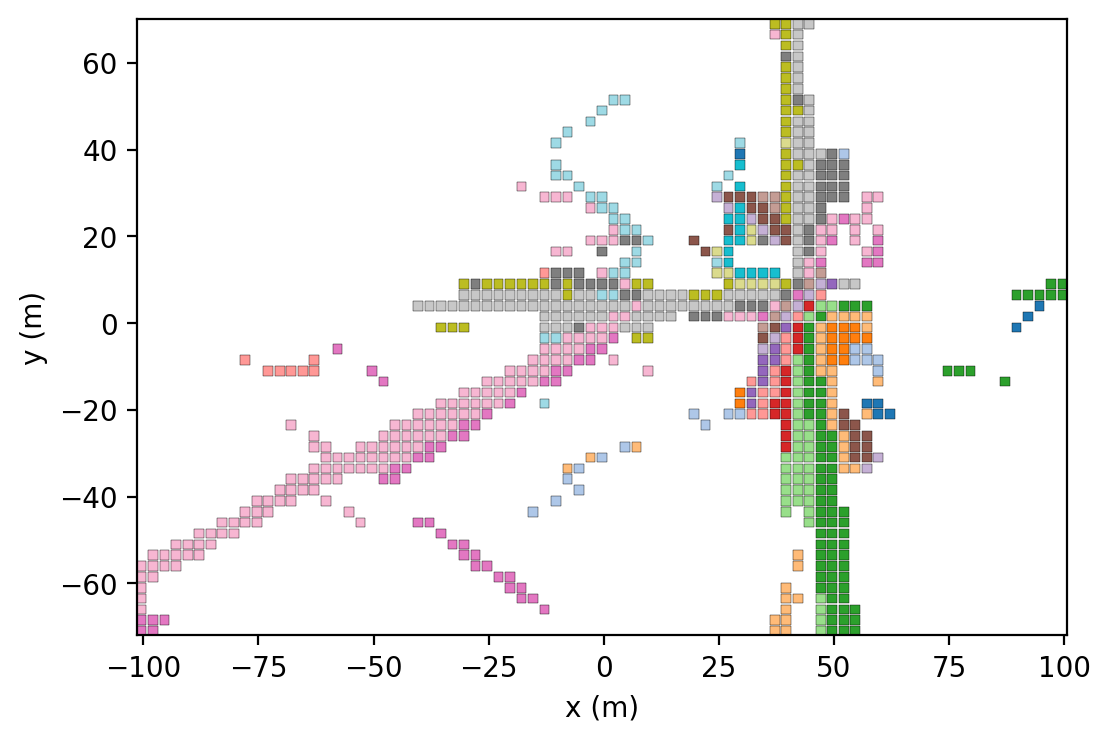


Basestation 1

UE-BS Channels


Computing the channel for each user: 100%|██████████| 4480/4480 [00:00<00:00, 329784.86it/s]


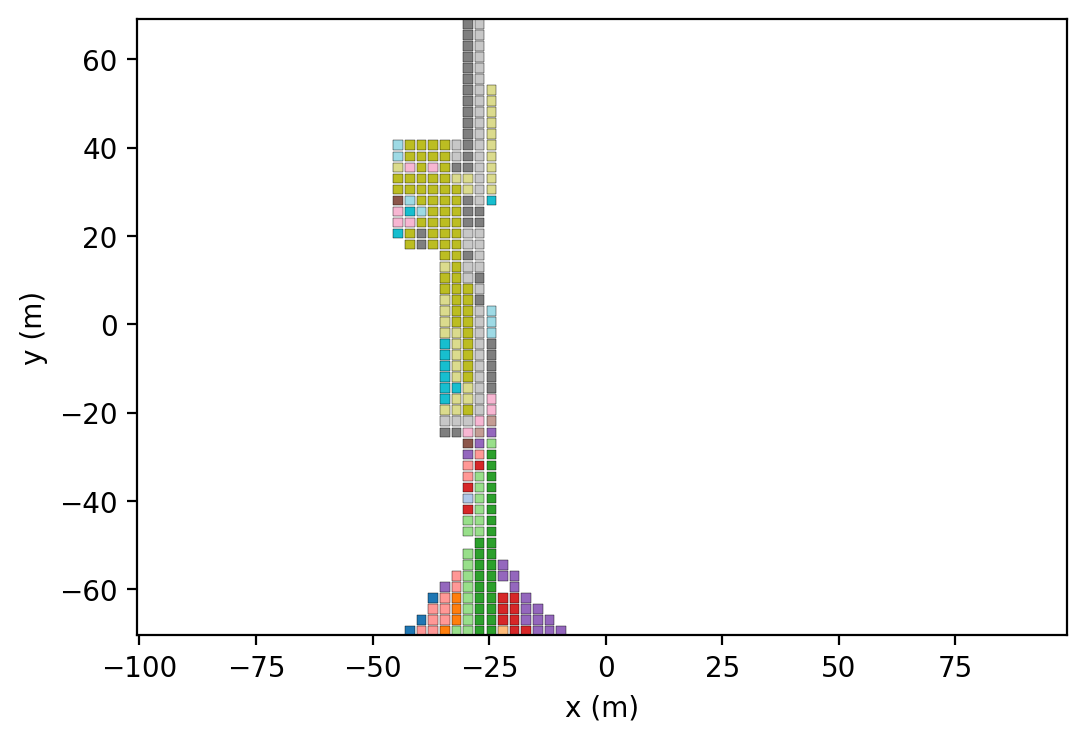

using cls_emb for Beam Prediction task
labels:  <class 'torch.Tensor'> 2308


In [6]:
################Select Tasks#################################and change beams############
#generate targets/lables
from input_preprocess import create_labels
tasks = ['LoS/NLoS Classification', 'Beam Prediction']
task = tasks[1] # Choose 0 for LoS/NLoS labels or 1 for beam prediction labels.
labels = create_labels(task, selected_scenario_names, n_beams=64)
print("using",selected_input_type,"for",task,"task")
print("labels: ",
    type(labels),len(labels)
)

In [7]:
#function to combine data and labels and split in the given train ratio ratio
def get_data_loaders(data_tensor, labels_tensor, batch_size=32, train_ratio=0.8):
    dataset = TensorDataset(data_tensor, labels_tensor)
    N = len(dataset)

    train_size = int(train_ratio * N)
    remaining = N - train_size
    val_size = remaining // 2
    test_size = remaining - val_size

    train_dataset, val_dataset, test_dataset = random_split(dataset,[train_size, val_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [8]:
###############CHANGE MAPPING ACCORDINGLY#######################333

# Mapping for beam prediction input types.
mapping = {
    'cls_emb': {'input_channels': 1, 'sequence_length': 64},
    'channel_emb': {'input_channels': 64, 'sequence_length': 128},
    'raw': {'input_channels': 16, 'sequence_length': 128}
}
input_type = selected_input_type  # use the same type as for data generation
params = mapping.get(input_type, mapping[selected_input_type]) #change if chosen anything else
n_beams = 64  # adjust as needed
initial_lr = 0.001
num_classes = n_beams + 1  # as defined in your code
print(selected_input_type)

cls_emb


In [9]:
# Define Residual Block and the 1D CNN model.
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )
    
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += self.shortcut(residual)
        x = F.relu(x)
        return x

class res1dcnn(nn.Module):
    def __init__(self, input_channels, sequence_length, num_classes):
        super(res1dcnn, self).__init__()
        # Initial convolution and pooling layers.
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        # Residual layers.
        self.layer1 = self._make_layer(32, 32, 2)
        self.layer2 = self._make_layer(32, 64, 3)
        self.layer3 = self._make_layer(64, 128, 4)
        # Compute flattened feature size.
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, sequence_length)
            dummy_output = self.compute_conv_output(dummy_input)
            self.flatten_size = dummy_output.numel()
        # Fully connected layers.
        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def _make_layer(self, in_channels, out_channels, num_blocks):
        layers = [ResidualBlock(in_channels, out_channels)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def compute_conv_output(self, x):
        x = self.maxpool(F.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = F.adaptive_avg_pool1d(x, 1)
        return x
    
    def forward(self, x):
        # Expect x shape: [batch, sequence_length, input_channels]
        x = x.transpose(1, 2)  # -> [batch, input_channels, sequence_length]
        x = self.compute_conv_output(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [10]:
# Function to plot training metrics.
def plot_training_metrics(epochs, train_losses, val_losses, val_f1_scores, save_path=None):
    plt.figure(figsize=(12, 5))
    # Loss plot.
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    # F1 score plot.
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_f1_scores, label='Validation Weighted F1', marker='o', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Weighted F1 Score')
    plt.title('F1 Score Curve')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

initiated results.txt
---------------------------- training Details ----------------------------
Dataset Size: 2308, shape: torch.Size([2308, 64])
epochs: 30, batch size: 32, input type: cls_emb
task: Beam Prediction

--- Starting training for split ratio: 0.005 ---
train: 1 | validate: 36 | test: 36


Epoch 1/30: Train Loss: 4.2295 | Val Loss: 4.1650 | Val Weighted F1: 0.0004


Epoch 2/30: Train Loss: 3.6696 | Val Loss: 4.1642 | Val Weighted F1: 0.0004


Epoch 3/30: Train Loss: 2.9545 | Val Loss: 4.1625 | Val Weighted F1: 0.0004


Epoch 4/30: Train Loss: 2.6332 | Val Loss: 4.1607 | Val Weighted F1: 0.0039


...

Epoch 29/30: Train Loss: 1.1927 | Val Loss: 4.3018 | Val Weighted F1: 0.0039


Epoch 30/30: Train Loss: 0.7938 | Val Loss: 4.3048 | Val Weighted F1: 0.0039


Testing: 100%|██████████| 36/36 [00:00<00:00, 560.86it/s]


Test Loss: 4.3455, Test Accuracy: 2.79%, Test F1: 0.0015
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

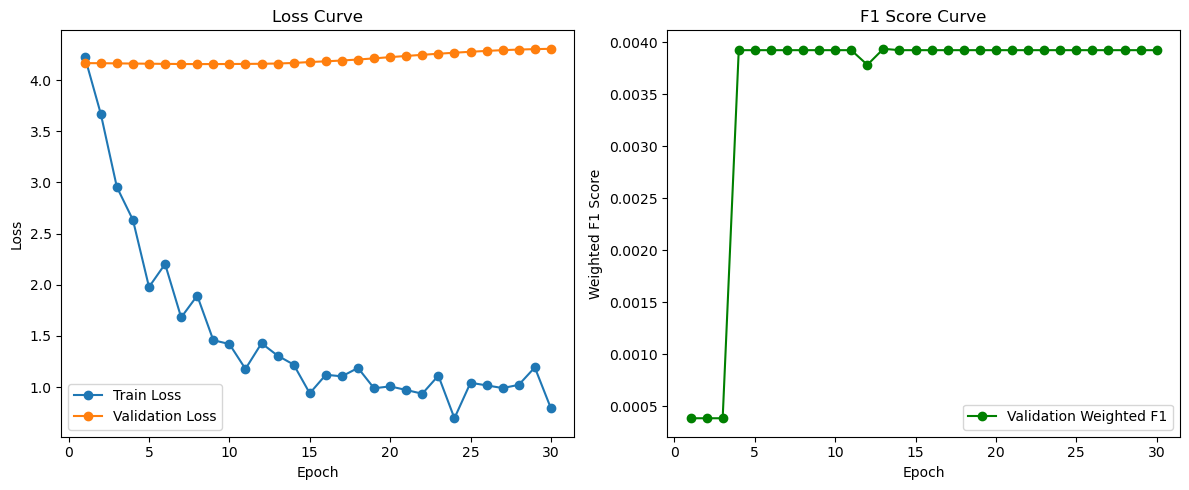

Plot saved as cls_emb_0.005.png

--- Starting training for split ratio: 0.01 ---
train: 1 | validate: 36 | test: 36


Epoch 1/30: Train Loss: 4.1305 | Val Loss: 4.1722 | Val Weighted F1: 0.0024


Epoch 2/30: Train Loss: 3.5516 | Val Loss: 4.1698 | Val Weighted F1: 0.0024


Epoch 3/30: Train Loss: 3.2093 | Val Loss: 4.1682 | Val Weighted F1: 0.0024


Epoch 4/30: Train Loss: 2.7579 | Val Loss: 4.1668 | Val Weighted F1: 0.0024


...

Epoch 30/30: Train Loss: 1.0642 | Val Loss: 4.8872 | Val Weighted F1: 0.0008


Testing: 100%|██████████| 36/36 [00:00<00:00, 703.86it/s]


Test Loss: 4.8934, Test Accuracy: 2.45%, Test F1: 0.0012
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

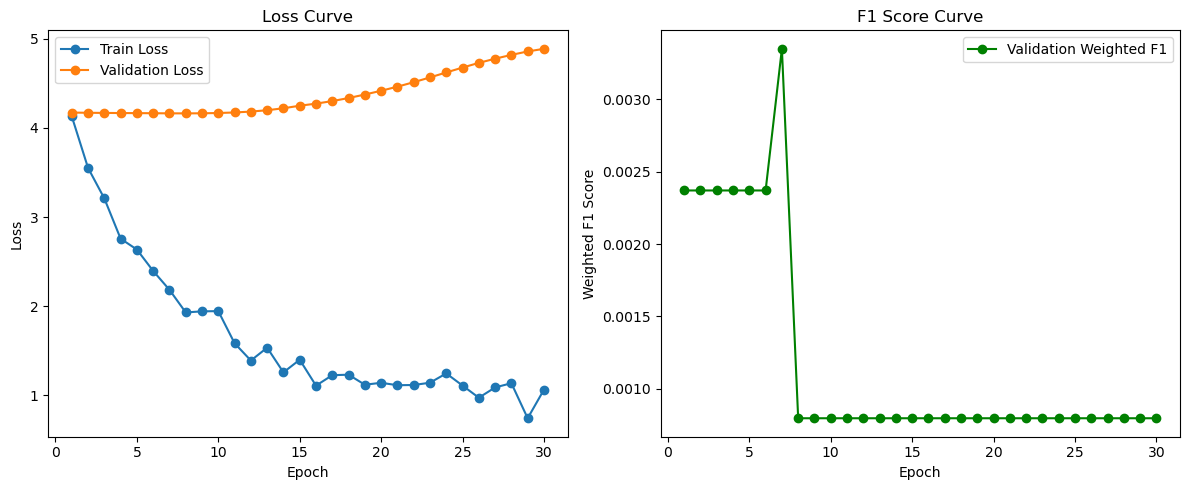

Plot saved as cls_emb_0.01.png

--- Starting training for split ratio: 0.05 ---
train: 4 | validate: 35 | test: 35


Epoch 1/30: Train Loss: 4.2411 | Val Loss: 4.1659 | Val Weighted F1: 0.0016


Epoch 2/30: Train Loss: 3.6912 | Val Loss: 4.1622 | Val Weighted F1: 0.0016


Epoch 3/30: Train Loss: 3.3832 | Val Loss: 4.1547 | Val Weighted F1: 0.0016


Epoch 4/30: Train Loss: 3.1704 | Val Loss: 4.1606 | Val Weighted F1: 0.0016


...

Epoch 30/30: Train Loss: 0.7855 | Val Loss: 3.7890 | Val Weighted F1: 0.0955


Testing: 100%|██████████| 35/35 [00:00<00:00, 610.84it/s]


Test Loss: 3.9197, Test Accuracy: 12.22%, Test F1: 0.0883
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

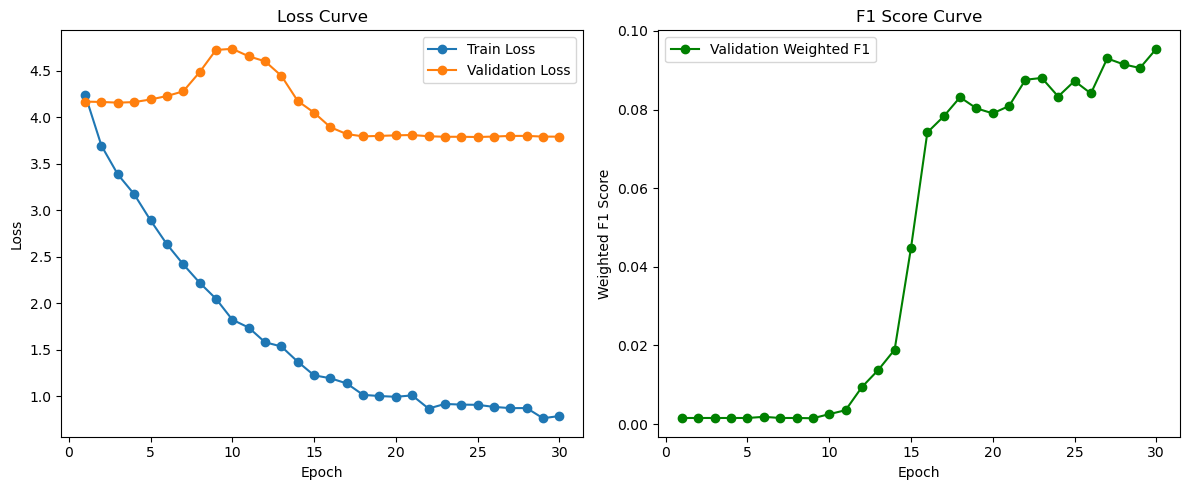

Plot saved as cls_emb_0.05.png

--- Starting training for split ratio: 0.1 ---
train: 8 | validate: 33 | test: 33


Epoch 1/30: Train Loss: 4.2752 | Val Loss: 4.1558 | Val Weighted F1: 0.0038


Epoch 2/30: Train Loss: 3.9044 | Val Loss: 4.1557 | Val Weighted F1: 0.0018


Epoch 3/30: Train Loss: 3.5423 | Val Loss: 4.3447 | Val Weighted F1: 0.0018


Epoch 4/30: Train Loss: 3.2743 | Val Loss: 4.5613 | Val Weighted F1: 0.0018


...

Epoch 30/30: Train Loss: 1.0409 | Val Loss: 3.4254 | Val Weighted F1: 0.1275


Testing: 100%|██████████| 33/33 [00:00<00:00, 642.40it/s]


Test Loss: 3.4543, Test Accuracy: 14.15%, Test F1: 0.1164
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

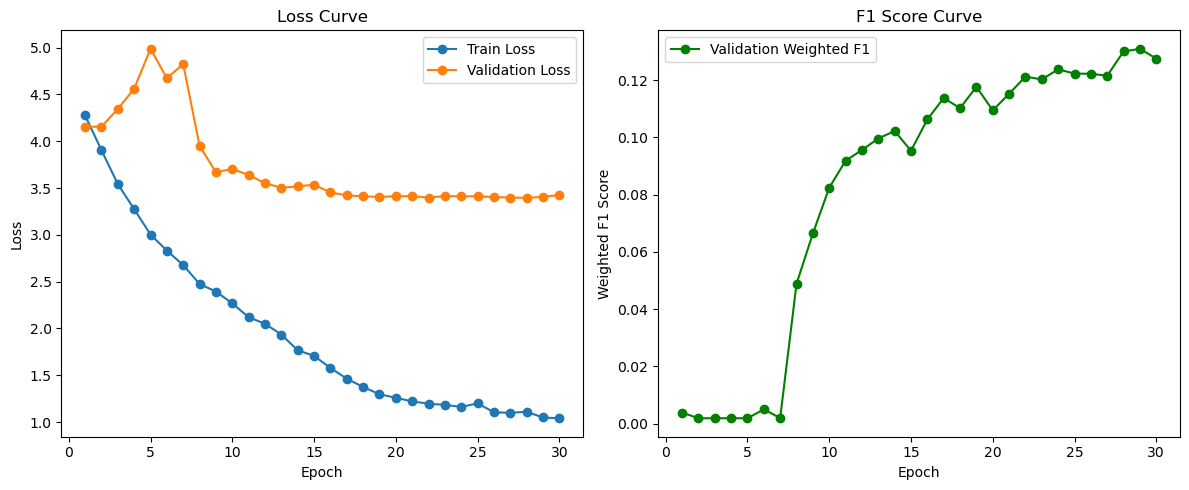

Plot saved as cls_emb_0.1.png

--- Starting training for split ratio: 0.2 ---
train: 15 | validate: 29 | test: 29


Epoch 1/30: Train Loss: 4.1914 | Val Loss: 4.1692 | Val Weighted F1: 0.0002


Epoch 2/30: Train Loss: 3.7899 | Val Loss: 4.6955 | Val Weighted F1: 0.0023


Epoch 3/30: Train Loss: 3.5331 | Val Loss: 4.4919 | Val Weighted F1: 0.0027


Epoch 4/30: Train Loss: 3.2985 | Val Loss: 3.6005 | Val Weighted F1: 0.0508


...

Epoch 30/30: Train Loss: 1.3123 | Val Loss: 2.9718 | Val Weighted F1: 0.1885


Testing: 100%|██████████| 29/29 [00:00<00:00, 615.14it/s]


Test Loss: 2.9205, Test Accuracy: 22.84%, Test F1: 0.1936
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

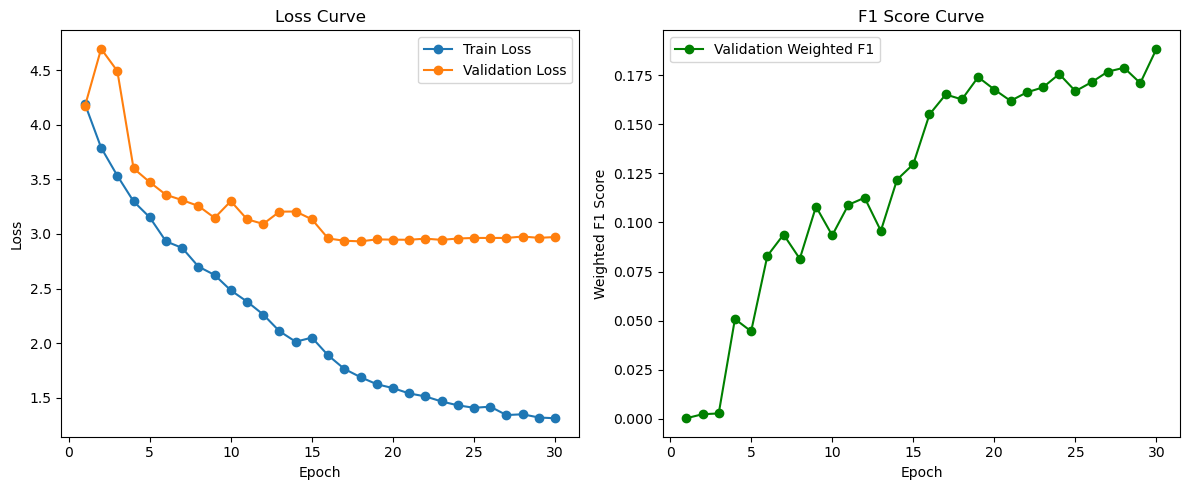

Plot saved as cls_emb_0.2.png

--- Starting training for split ratio: 0.4 ---
train: 29 | validate: 22 | test: 22


Epoch 1/30: Train Loss: 4.0004 | Val Loss: 4.6713 | Val Weighted F1: 0.0017


Epoch 2/30: Train Loss: 3.4803 | Val Loss: 4.0973 | Val Weighted F1: 0.0132


Epoch 3/30: Train Loss: 3.1698 | Val Loss: 3.1869 | Val Weighted F1: 0.0740


Epoch 4/30: Train Loss: 2.9686 | Val Loss: 3.0016 | Val Weighted F1: 0.1002


...

Epoch 30/30: Train Loss: 1.3407 | Val Loss: 2.1465 | Val Weighted F1: 0.2522


Testing: 100%|██████████| 22/22 [00:00<00:00, 565.33it/s]

Test Loss: 2.1678, Test Accuracy: 31.31%, Test F1: 0.2795
Results saved to results.txt


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

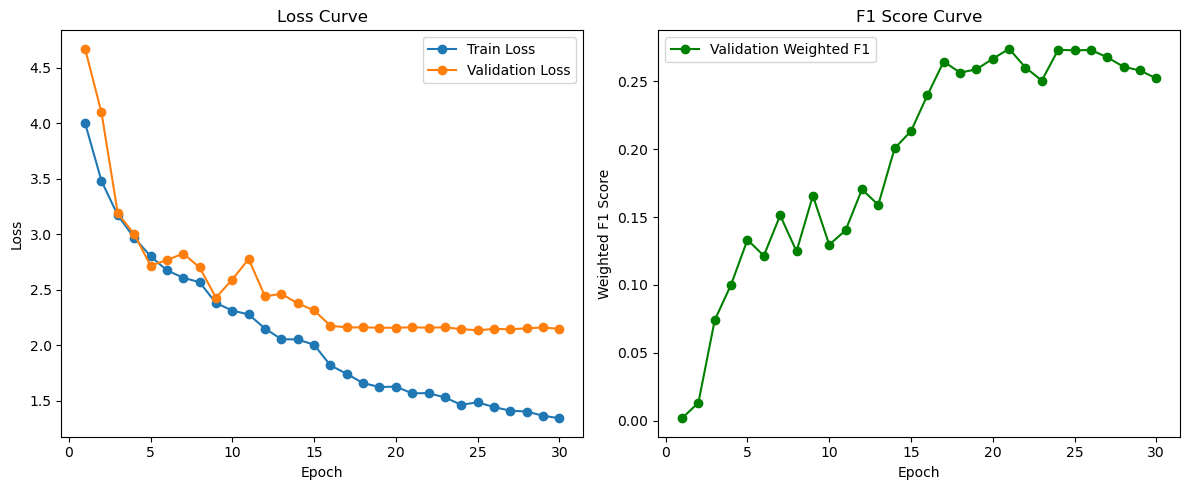

Plot saved as cls_emb_0.4.png


<Figure size 640x480 with 0 Axes>

In [11]:
num_epochs = 30
batch_size = 32  # Set a value (adjust as needed)

# Initial log (Header)
message = (
    "---------------------------- training Details ----------------------------\n"
    f"Dataset Size: {len(dataset)}, shape: {dataset.shape}\n"
    f"epochs: {num_epochs}, "
    f"batch size: {batch_size}, "
    f"input type: {selected_input_type}\n"
    f"task: {task}"
)

# Write header to file
with open("results.txt", "a") as f:
    f.write("\n" + message)
print("initiated results.txt")
print(message)

# Define the split ratios to iterate over
split_ratios = [0.005, 0.01, 0.05, 0.1, 0.2, 0.4]

for split_ratio in split_ratios:
    print(f"\n--- Starting training for split ratio: {split_ratio} ---")

    # Instantiate the model FRESH for every split ratio (train from scratch)
    beam_model = res1dcnn(params['input_channels'], params['sequence_length'], num_classes).to(device)
    optimizer = Adam(beam_model.parameters(), lr=initial_lr)
    scheduler = MultiStepLR(optimizer, milestones=[15, 35], gamma=0.1)
    
    # Get DataLoaders for the current split_ratio
    train_loader, val_loader, test_loader = get_data_loaders(dataset, labels, train_ratio=split_ratio)
    
    print(f"train: {len(train_loader)} | validate: {len(val_loader)} | test: {len(test_loader)}")
    
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_losses = []
    val_f1_scores = []
    epochs_list = []

    # -----------------------------
    # Training Loop
    # -----------------------------
    for epoch in range(1, num_epochs + 1):
        beam_model.train()
        running_loss = 0.0
        # Training with tqdm progress bar.
        for data, target in tqdm(train_loader, desc=f"Epoch {epoch} Training", leave=False):
            data, target = data.to(device), target.to(device)
            # Adjust input shape based on type.
            if input_type == 'raw':
                data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
            elif input_type == 'cls_emb':
                data = data.unsqueeze(2)
            optimizer.zero_grad()
            outputs = beam_model(data)
            loss = criterion(outputs, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(beam_model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * data.size(0)
        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        # Validation loop with tqdm.
        beam_model.eval()
        val_running_loss = 0.0
        all_preds = []
        all_targets = []
        for data, target in tqdm(val_loader, desc=f"Epoch {epoch} Validation", leave=False):
            data, target = data.to(device), target.to(device)
            if input_type == 'raw':
                data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
            elif input_type == 'cls_emb':
                data = data.unsqueeze(2)
            outputs = beam_model(data)
            loss = criterion(outputs, target)
            val_running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
        val_loss = val_running_loss / len(val_loader.dataset)
        val_f1 = f1_score(all_targets, all_preds, average='weighted')

        epochs_list.append(epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch}/{num_epochs}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Weighted F1: {val_f1:.4f}")

    # -----------------------------
    # Test Loop (After Training)
    # -----------------------------
    beam_model.eval()
    test_running_loss = 0.0
    all_preds_test = []
    all_targets_test = []
    correct = 0
    total = 0
    
    for data, target in tqdm(test_loader, desc="Testing"):
        data, target = data.to(device), target.to(device)
        if input_type == 'raw':
            data = data.view(data.size(0), params['sequence_length'], params['input_channels'])
        elif input_type == 'cls_emb':
            data = data.unsqueeze(2)
        outputs = beam_model(data)
        loss = criterion(outputs, target)
        test_running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
        all_preds_test.extend(predicted.cpu().numpy())
        all_targets_test.extend(target.cpu().numpy())
        
    test_loss = test_running_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total
    test_f1 = f1_score(all_targets_test, all_preds_test, average='weighted')
    
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {accuracy:.2f}%, Test F1: {test_f1:.4f}")

    # -----------------------------
    # Save results to file
    # -----------------------------
    with open("results.txt", "a") as f:
        f.write(
            f"\nSplit Ratio: {split_ratio} | "
            f"Test Accuracy: {accuracy:.2f}% | "
            f"Test F1: {test_f1:.4f}\n"
        )
    print("Results saved to results.txt")

    # -----------------------------
    # Save plot
    # -----------------------------
    fig = plt.figure()
    plot_training_metrics(epochs_list, train_losses, val_losses, val_f1_scores)
    plt.savefig(f"{selected_input_type}_{split_ratio}.png", bbox_inches='tight')
    plt.close(fig)
    print(f"Plot saved as {selected_input_type}_{split_ratio}.png")